<a href="https://www.kaggle.com/code/asishjosekakkadan/multivariate-forecast?scriptVersionId=273160995" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
!pip install pmdarima --quiet

# House Property Sales Forecasting using Multivariate Time Series Models

The task of this project is to perform **multivariate time series forecasting** on the *House Property Sales* dataset (2007–2019).  
The goal is to analyze historical property sales trends and build predictive models to forecast future house property prices using multiple time-dependent and feature-based variables such as property type, number of bedrooms, and location.

**Key Steps:**
- Data Preprocessing  
- Exploratory Data Analysis (EDA)  
- Feature Engineering  
- Model Implementation 
- Model Evaluation  
- Insights and Interpretation  

📈 **Objective:** To develop and compare forecasting models that accurately predict future house property prices based on historical and feature-driven data.


In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv('/kaggle/input/property-sales/raw_sales.csv')
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


## Preprocessing and EDA

#### Overview

In [5]:
df = data.copy()

In [6]:
df = data.rename(columns={'datesold':'date',
                         'propertyType':'type'})

In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      29580 non-null  datetime64[ns]
 1   postcode  29580 non-null  int64         
 2   price     29580 non-null  int64         
 3   type      29580 non-null  object        
 4   bedrooms  29580 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


In [9]:
df.describe()

,date,postcode,price,bedrooms
count,29580,29580.000000,2.958000e+04,29580.000000
mean,2015-02-21 07:35:42.474644992,2730.249730,6.097363e+05,3.250169
min,2007-02-07 00:00:00,2600.000000,5.650000e+04,0.000000
25%,2013-02-05 00:00:00,2607.000000,4.400000e+05,3.000000
50%,2015-09-30 00:00:00,2615.000000,5.500000e+05,3.000000
75%,2017-07-26 00:00:00,2905.000000,7.050000e+05,4.000000
max,2019-07-27 00:00:00,2914.000000,8.000000e+06,5.000000
std,NaN,146.717292,2.817079e+05,0.951275


#### Average Price By Property Type

In [10]:
avg_price_by_type = df.groupby('type')['price'].mean().sort_values(ascending=False)
print(avg_price_by_type)

type
house    647956.128462
unit     423106.557279
Name: price, dtype: float64


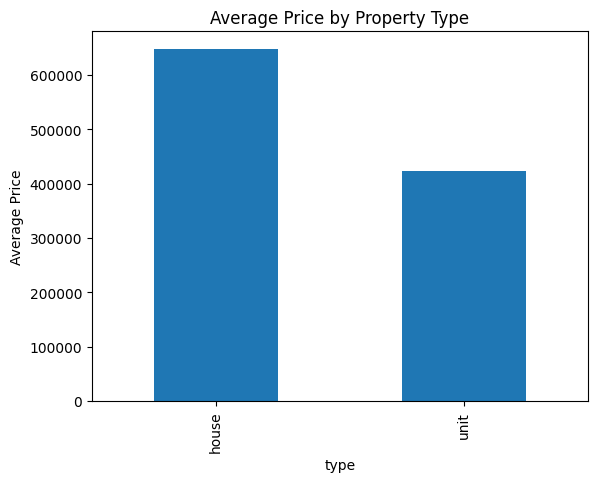

In [11]:
avg_price_by_type.plot(kind='bar', title='Average Price by Property Type')
plt.ylabel('Average Price')
plt.show()

#### Average Price by Number of Bedrooms

bedrooms
5    919056.058974
4    718171.142023
3    552304.428140
0    542300.000000
2    442222.917454
1    335992.905962
Name: price, dtype: float64


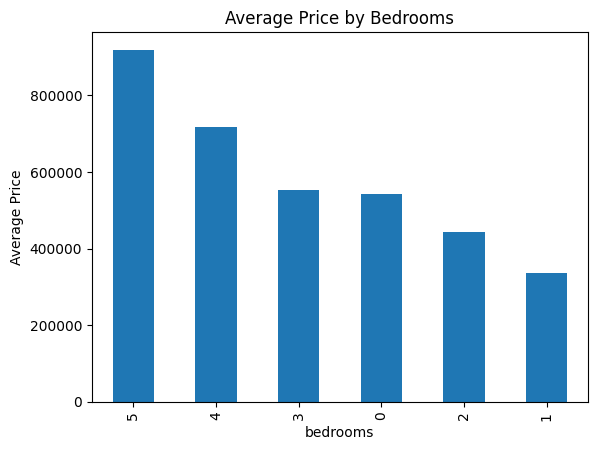

In [12]:
avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)
print(avg_price_by_bedrooms)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.show()

Here we can consider the bedroom count 0 as missing values in number of bedrooms column

#### Impute bedrooms for rows with 0 using price thresholds

In [13]:
df[df['bedrooms']==0].head()

,date,postcode,price,type,bedrooms
5801,2012-09-10,2913,415000,house,0
6484,2013-02-02,2605,840000,house,0
6497,2013-02-06,2604,490000,house,0
6917,2013-05-07,2600,725000,house,0
7167,2013-06-28,2606,630000,house,0


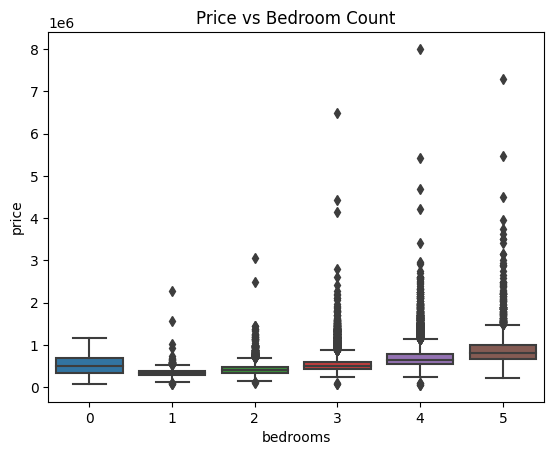

In [14]:
sns.boxplot(x='bedrooms', y='price', data=df)
plt.title('Price vs Bedroom Count')
plt.show()

In [15]:
price_stats = df.groupby('bedrooms')['price'].median()
print(price_stats)

bedrooms
0    504500.0
1    327000.0
2    410000.0
3    499000.0
4    650000.0
5    805500.0
Name: price, dtype: float64


In [16]:
df['postcode'].nunique()

27

In [17]:
# KNNImputer

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

df['bedrooms'] = df['bedrooms'].replace(0,np.nan)

le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

features = ['price', 'type_encoded', 'bedrooms']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = imputer.fit_transform(X_scaled)
X_unscaled = scaler.inverse_transform(X_imputed)
df['bedrooms'] = X_unscaled[:,2]

df['bedrooms'] = df['bedrooms'].round().astype(int)
df['bedrooms'] = df['bedrooms'].clip(lower=1, upper=5)
df['bedrooms'].value_counts()

bedrooms
3    11939
4    10450
2     3604
5     1954
1     1633
Name: count, dtype: int64

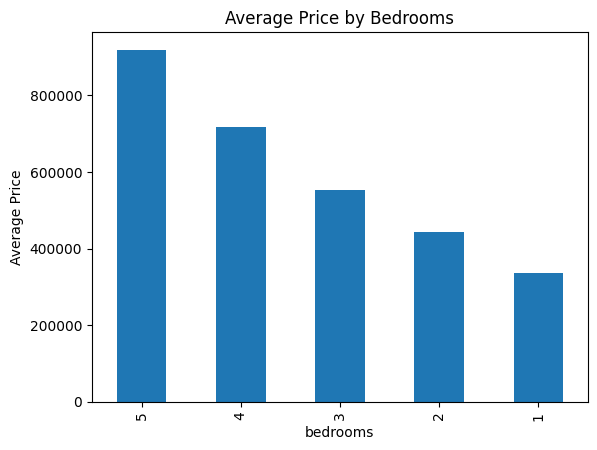

In [18]:
avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.show()

Now it makes sense right!

#### Average Price by Postcode

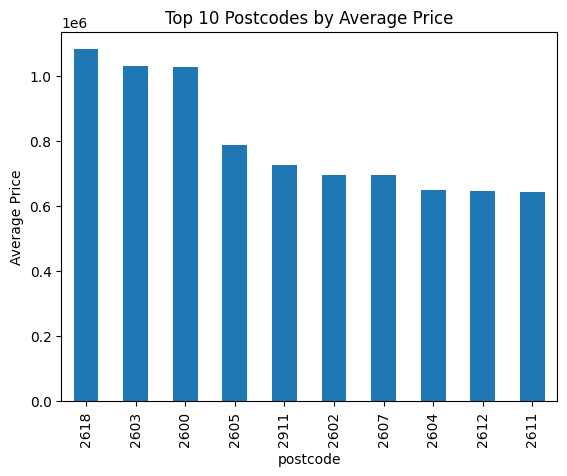

In [19]:
avg_price_by_postcode = df.groupby('postcode')['price'].mean().sort_values(ascending=False).head(10)

avg_price_by_postcode.plot(kind='bar', title='Top 10 Postcodes by Average Price')
plt.ylabel('Average Price')
plt.show()


#### Correlation

In [20]:
df.columns

Index(['date', 'postcode', 'price', 'type', 'bedrooms', 'type_encoded'], dtype='object')

In [21]:
numeric_features = ['price', 'bedrooms']

In [22]:
df[numeric_features].corr(numeric_only=True)

,price,bedrooms
price,1.000000,0.487047
bedrooms,0.487047,1.000000


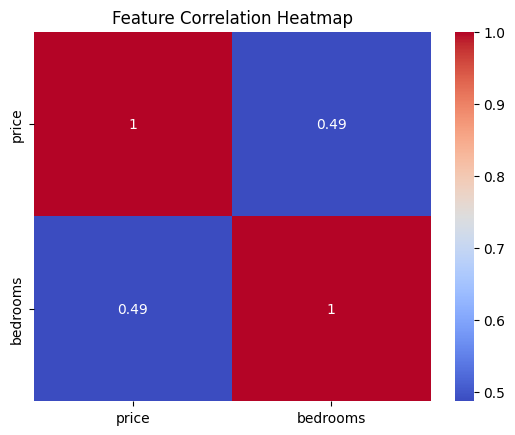

In [23]:
sns.heatmap(df[numeric_features].corr(numeric_only=True),annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

#### Data Distribution

In [24]:
num_features = ['price','bedrooms']
cat_features = ['postcode','type']

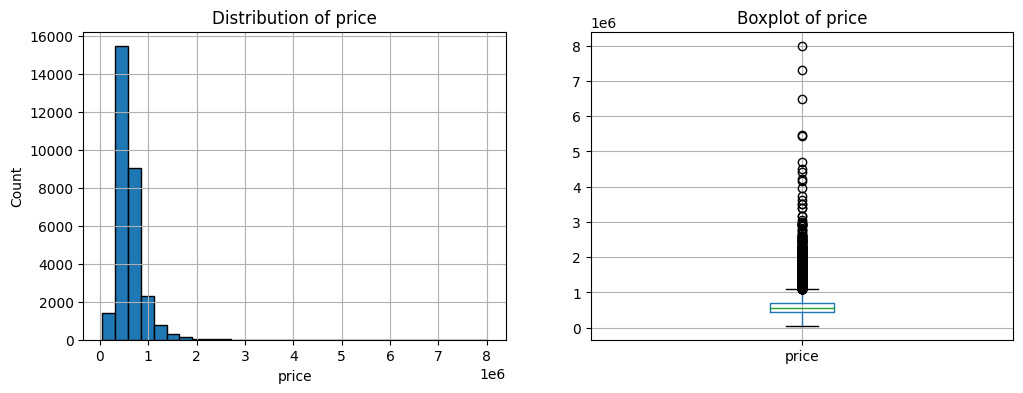

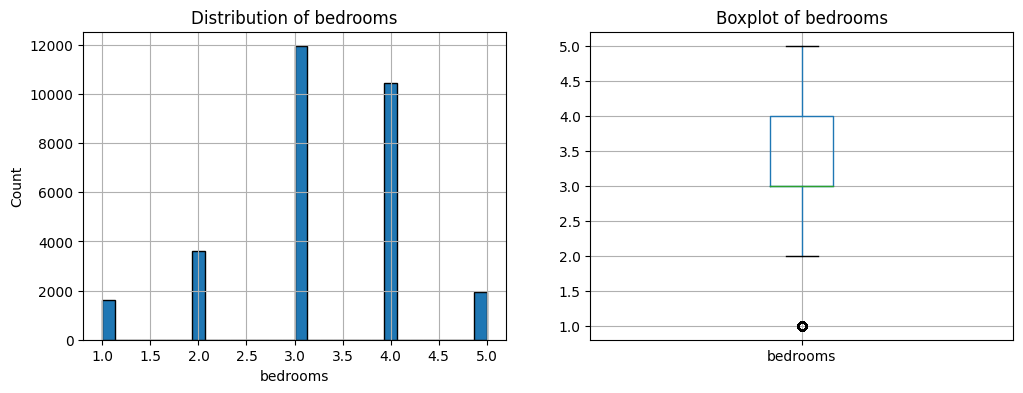

In [25]:
for col in num_features:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    df[col].hist(bins=30, edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    df.boxplot(column=col)
    plt.title(f"Boxplot of {col}")

    plt.show()

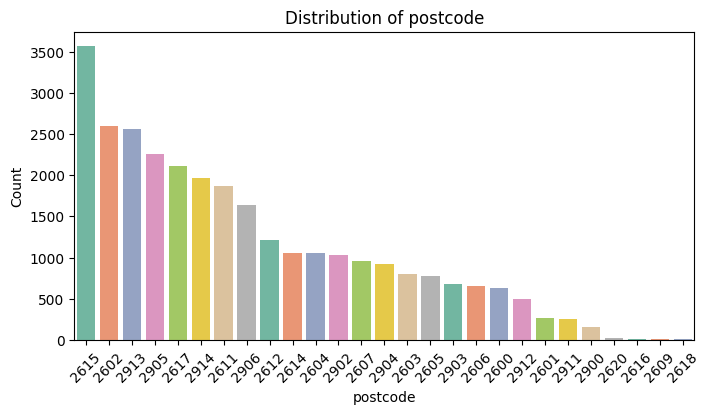

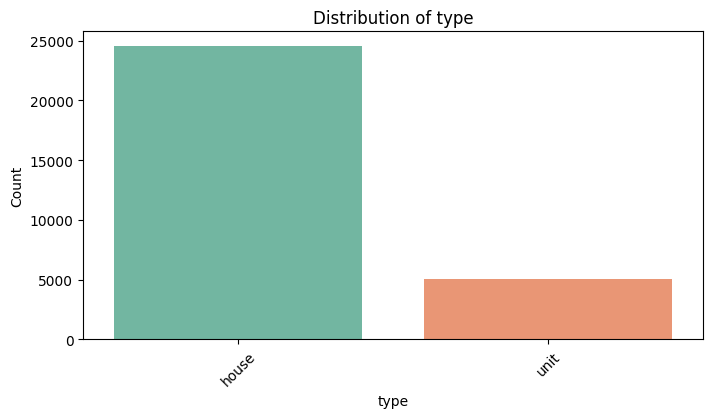

In [26]:
for col in cat_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

#### Transforming Price

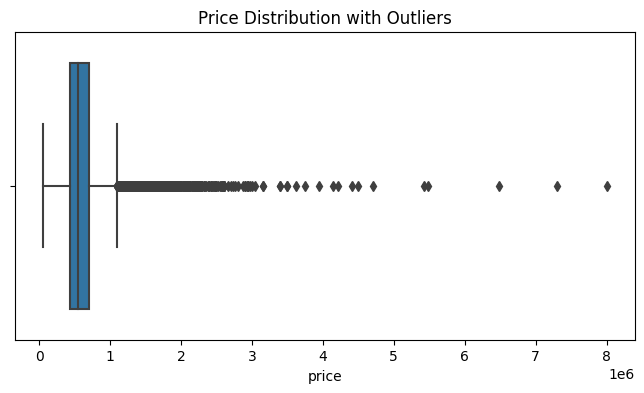

In [27]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['price'])
plt.title("Price Distribution with Outliers")
plt.show()

In [28]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Outliers detected: {len(outliers)}")

Outliers detected: 1374


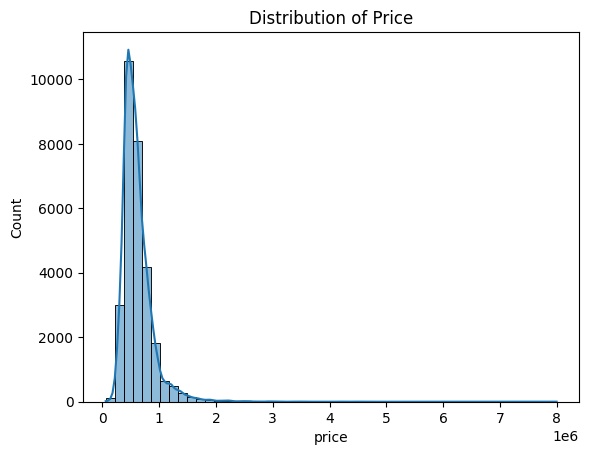

In [29]:
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Distribution of Price")
plt.show()

Log transform price - It helps reduce extreme price variance and improves convergence.

In [30]:
df['log_price'] = np.log1p(df['price'])

# predicted_price = np.expm1(predicted_log_price) (converting back)

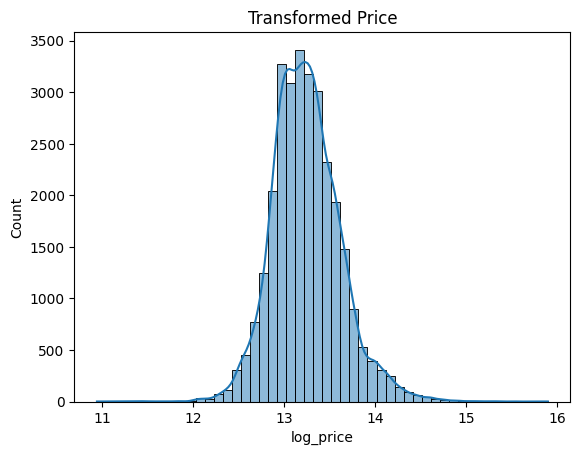

In [31]:
sns.histplot(df['log_price'], bins=50, kde=True)
plt.title("Transformed Price")
plt.show()

##### Log Transformation of Target Variable (`price`)

The `price` variable in our dataset is heavily **right-skewed**, meaning most properties have relatively low prices, while a few luxury homes are extremely expensive.  
Such skewness is natural in real estate markets but poses a problem for time series forecasting models like **SARIMAX**, **Prophet**, and **LSTM**, which assume the target variable is roughly **stationary and homoscedastic** (constant variance).

To stabilize variance and reduce the impact of extreme values, we apply a **log transformation** to the target variable:

\[
\text{log\_price} = \log(1 + \text{price})
\]

This transformation:
- Compresses the range of high values (reduces outlier influence).  
- Makes the distribution more symmetric and closer to normal.  
- Helps forecasting models capture percentage-based growth patterns more effectively.  

We will therefore use **`log_price`** for modeling and convert predictions back to the original scale using the exponential function:

\[
predicted_price = np.expm1(predicted_log_price) (converting back)
\]


#### Aggregate by month

In [32]:
monthly = df.resample('M', on='date').agg({'price':'median'})

In [33]:
monthly = df.resample('M', on='date').agg({
    'price': 'median',
    'bedrooms': lambda x: round(x.median()),  
    'type': lambda x: x.mode()[0] if not x.mode().empty else np.nan,
    'postcode': lambda x: x.mode()[0] if not x.mode().empty else np.nan
}).reset_index()


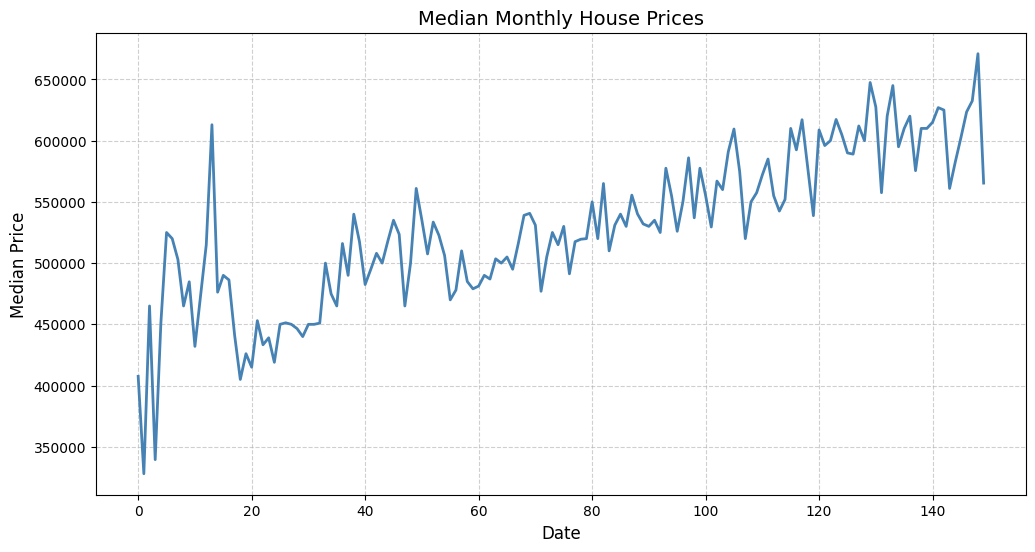

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly['price'], color='steelblue', linewidth=2)
plt.title('Median Monthly House Prices', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Median Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

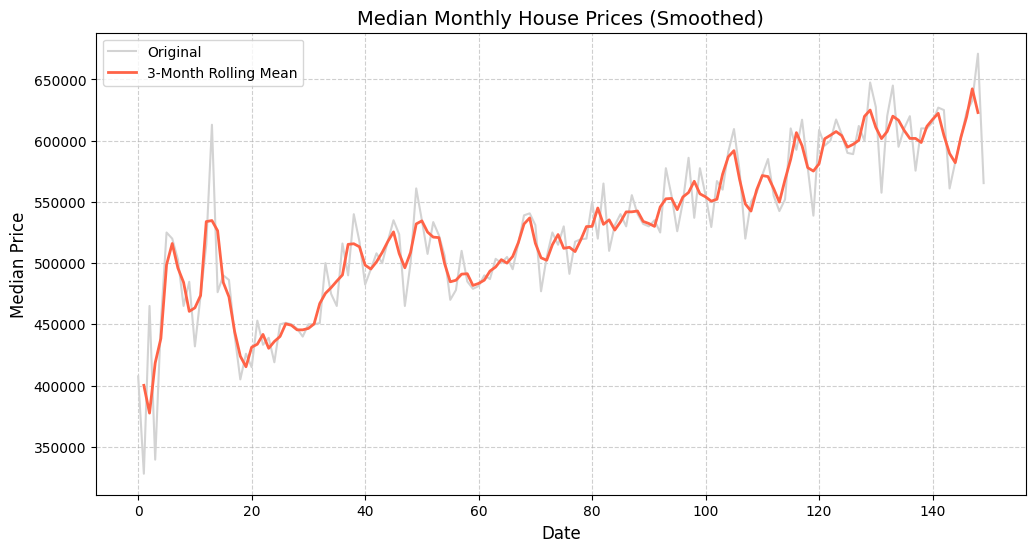

In [35]:
monthly['price_rolling'] = monthly['price'].rolling(window=3, center=True).mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly['price'], color='lightgray', label='Original', linewidth=1.5)
plt.plot(monthly.index, monthly['price_rolling'], color='tomato', label='3-Month Rolling Mean', linewidth=2)
plt.title('Median Monthly House Prices (Smoothed)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Median Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Model Building

In [36]:
df.head()

,date,postcode,price,type,bedrooms,type_encoded,log_price
0,2007-02-07,2607,525000,house,4,0,13.171155
1,2007-02-27,2906,290000,house,3,0,12.577640
2,2007-03-07,2905,328000,house,3,0,12.700772
3,2007-03-09,2905,380000,house,4,0,12.847929
4,2007-03-21,2906,310000,house,3,0,12.644331


Here the features like bedrooms, type, postcode, etc exists at the individual property level (i.e., per transaction).
But SARIMAX expects time series-level features — one observation per time step (like per month).

- Endogenous variable (y): price (target variable)
- Exogenous variables (X):(features that explain y) avg_bedrooms, house_ratio, sales_count

We can't use categorical features like type, postcode, etc as exogenous variables,
for that we need to create aggregate features like:
- avg_bedrooms → mean bedrooms per month
- house_ratio → fraction of properties of type house per month
- sales_count → total properties sold per month (helps capture demand level)

### Monthly Aggregation with Regressors

In [37]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

In [38]:
monthly_df = (
    df.groupby('month').agg(
        price=('price', 'median'),                          
        avg_bedrooms=('bedrooms', 'mean'),                  
        house_ratio=('type', lambda x: (x == 'house').mean()), 
        sales_count=('price', 'count')                      
    )
    .reset_index()
)

In [39]:
monthly_df['month'] = monthly_df['month'].dt.to_timestamp()
monthly_df.set_index('month', inplace=True)

In [40]:
monthly_df.head()

,price,avg_bedrooms,house_ratio,sales_count
month,,,,
2007-02-01,407500.0,3.500000,1.000000,2
2007-03-01,328000.0,3.333333,1.000000,3
2007-04-01,465000.0,3.666667,1.000000,3
2007-05-01,339500.0,3.000000,1.000000,2
2007-06-01,451000.0,3.333333,0.833333,6


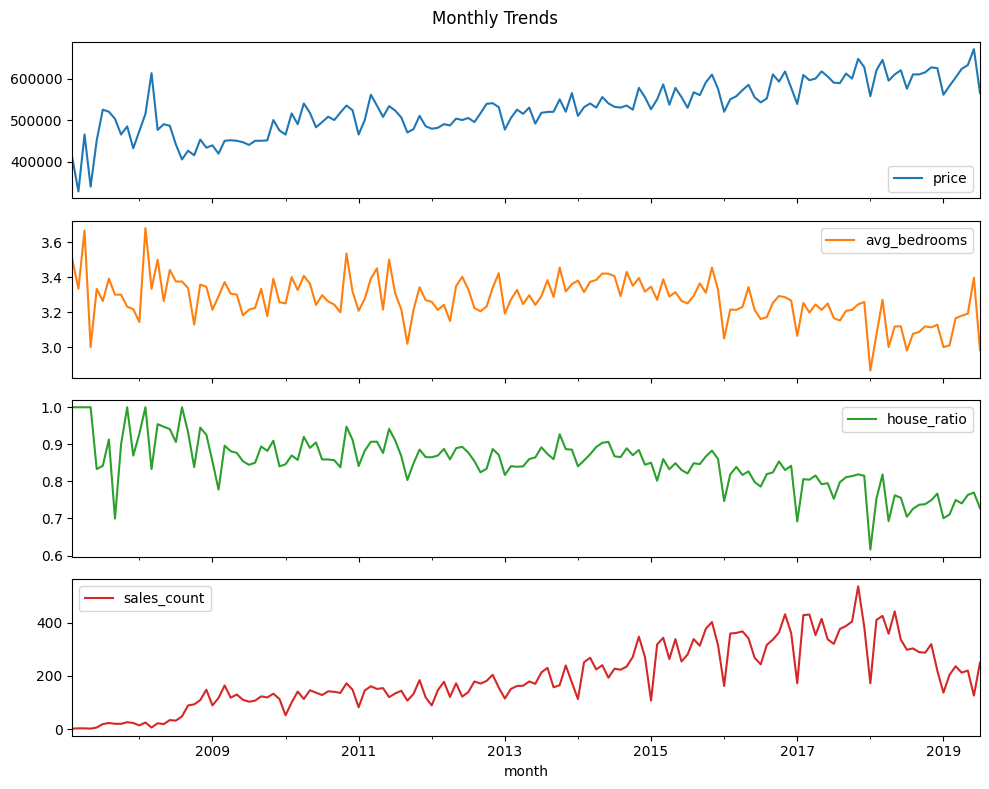

In [41]:
monthly_df[['price', 'avg_bedrooms', 'house_ratio', 'sales_count']].plot(
    subplots=True, figsize=(10, 8), title='Monthly Trends'
)
plt.tight_layout()
plt.show()

## SARIMAX

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

In [43]:
monthly_df = monthly_df.asfreq('MS')

train_size = int(len(monthly_df) * 0.85)
train = monthly_df.iloc[:train_size]
test = monthly_df.iloc[train_size:]

y_train = train['price']
y_test  = test['price']
X_train = train[['avg_bedrooms', 'house_ratio', 'sales_count']]
X_test  = test[['avg_bedrooms', 'house_ratio', 'sales_count']]

print(f"Train: {len(train)} | Test: {len(test)}")
print("Train range:", train.index.min(), "→", train.index.max())
print("Test range:", test.index.min(), "→", test.index.max())

Train: 127 | Test: 23
Train range: 2007-02-01 00:00:00 → 2017-08-01 00:00:00
Test range: 2017-09-01 00:00:00 → 2019-07-01 00:00:00


In [44]:
auto_model = auto_arima(
    y=y_train,
    exogenous=X_train,
    seasonal=True,
    m=12,                       
    trace=True,                  
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    max_p=3, max_q=3, max_P=2, max_Q=2,
    max_order=None,
    information_criterion='aic'  
)


print("Best model order:", auto_model.order)
print("Best seasonal order:", auto_model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.40 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=3016.816, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2992.496, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=3001.170, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3015.004, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2993.468, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2994.307, Time=0.30 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2992.916, Time=0.27 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=2992.585, Time=0.11 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=2994.373, Time=0.54 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=3018.613, Time=0.07 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=2993.403, Time=0.17 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=2994.075, Time=0.23 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=3001.235, Time=0.13 sec
 ARIMA(2,1,1)(1,0,0)[12]

In [45]:
model = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = model.fit(disp=False)
print(sarimax_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                   price   No. Observations:                  127
Model:             SARIMAX(1, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood               -1137.952
Date:                                 Mon, 03 Nov 2025   AIC                           2291.905
Time:                                         15:05:42   BIC                           2312.826
Sample:                                     02-01-2007   HQIC                          2300.374
                                          - 08-01-2017                                         
Covariance Type:                                   opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
avg_bedrooms  1.357e+05   5.55e+04      2.445      0.014    2.69e+04  

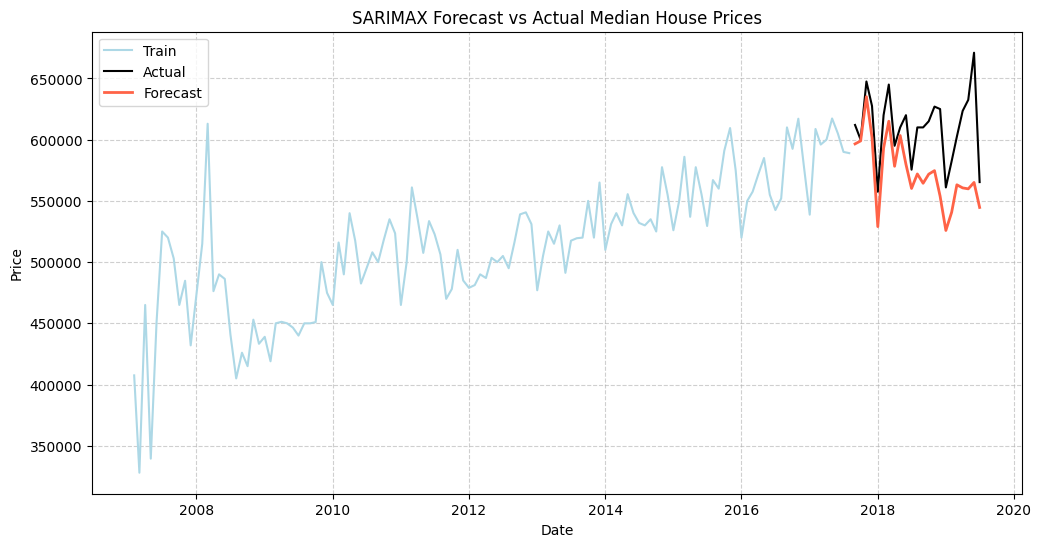

In [46]:
forecast = sarimax_fit.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test
)

plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Train', color='lightblue')
plt.plot(y_test.index, y_test, label='Actual', color='black')
plt.plot(y_test.index, forecast, label='Forecast', color='tomato', linewidth=2)
plt.title("SARIMAX Forecast vs Actual Median House Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

forecast = sarimax_fit.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test
)

mae = mean_absolute_error(y_test, forecast)
rmse = np.sqrt(mean_squared_error(y_test, forecast))
mape = np.mean(np.abs((y_test - forecast) / y_test)) * 100

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE : 36,850.81
RMSE: 43,867.60
MAPE: 5.97%


The SARIMAX model achieved a MAE of 36,904.47, RMSE of 43,930.70, and MAPE of 5.98%, indicating strong short-term accuracy with minimal percentage error. The model effectively captured short-term fluctuations but showed divergence in later periods.

This behavior suggests that while SARIMAX performs well initially, changing market dynamics or weaker regressors (like avg_bedrooms or house_ratio) may reduce long-term accuracy. Overall, the model demonstrates solid performance for short-term house price forecasting using multivariate time series data